# Stage 5: Nested model development and comparison

MLR, random forest, XGBoost and supplementary Balanced Random Forest are developed using the fixed training sample and nested cross-validation folds.

Inner folds select hyperparameters and imbalance handling using macro F1. Outer folds estimate development performance. The held-out test sample is not used in model development.

## Part 1: Inputs and development sample

In [1]:
# 1: Import packages and set project paths

from pathlib import Path
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
)
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "Stage 5 requires xgboost. Install it in the project environment before continuing."
    ) from exc

try:
    from imblearn.ensemble import BalancedRandomForestClassifier
except ImportError as exc:
    raise ImportError(
        "Stage 5 requires imbalanced-learn. Install it in the project environment before continuing."
    ) from exc

working_directory = Path.cwd().resolve()

# Locate the project root from the required Stage 3 and Stage 4 files.
project_root = next(
    (
        directory
        for directory in [working_directory, *working_directory.parents]
        if (
            directory
            / "data_derived"
            / "stage_3_final_modelling_dataset"
            / "final_modelling_dataset.csv"
        ).is_file()
        and (
            directory
            / "data_derived"
            / "stage_4_modelling_design"
            / "stage_4_model_search_specification.csv"
        ).is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "The Stage 3 modelling dataset and Stage 4 design files could not be located."
    )

data_derived = project_root / "data_derived"

stage_2_directory = data_derived / "stage_2_predictor_construction"
stage_3_directory = data_derived / "stage_3_final_modelling_dataset"
stage_4_directory = data_derived / "stage_4_modelling_design"
stage_5_directory = data_derived / "stage_5_nested_model_development"
stage_5_directory.mkdir(parents=True, exist_ok=True)

modelling_data_path = stage_3_directory / "final_modelling_dataset.csv"
predictor_manifest_path = stage_2_directory / "stage_2_final_predictor_manifest.csv"
split_path = stage_4_directory / "stage_4_train_test_split.csv"
outer_folds_path = stage_4_directory / "stage_4_outer_folds.csv"
inner_folds_path = stage_4_directory / "stage_4_inner_folds.csv"
predictor_roles_path = stage_4_directory / "stage_4_predictor_preprocessing_roles.csv"
model_search_path = stage_4_directory / "stage_4_model_search_specification.csv"

required_paths = [
    modelling_data_path,
    predictor_manifest_path,
    split_path,
    outer_folds_path,
    inner_folds_path,
    predictor_roles_path,
    model_search_path,
]

missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(
        "Missing required input file(s):\n"
        + "\n".join(str(path.relative_to(project_root)) for path in missing_paths)
    )

print("Project root located.")
print(
    "Stage 5 output directory:",
    stage_5_directory.relative_to(project_root).as_posix(),
)

Project root located.
Stage 5 output directory: data_derived/stage_5_nested_model_development


In [2]:
# 2: Load the fixed modelling inputs

split_assignment = pd.read_csv(split_path, dtype={"NSID": "string"})
outer_assignments = pd.read_csv(outer_folds_path, dtype={"NSID": "string"})
inner_assignments = pd.read_csv(inner_folds_path, dtype={"NSID": "string"})
predictor_roles = pd.read_csv(predictor_roles_path)
predictor_manifest = pd.read_csv(predictor_manifest_path)
stage_4_search_specification = pd.read_csv(model_search_path)

training_ids = set(
    split_assignment.loc[
        split_assignment["sample"].eq("Training"),
        "NSID",
    ]
)

test_ids = set(
    split_assignment.loc[
        split_assignment["sample"].eq("Test"),
        "NSID",
    ]
)

# Restrict all fitting in this notebook to the fixed training identifiers.
modelling_data = pd.read_csv(modelling_data_path, dtype={"NSID": "string"})
training_data = (
    modelling_data.loc[modelling_data["NSID"].isin(training_ids)]
    .copy()
    .reset_index(drop=True)
)

del modelling_data

# Preserve the registered predictor order for every model.
predictor_columns = predictor_roles["Predictor"].tolist()

print(f"Training participants: {len(training_data):,}")
print(f"Predictors: {len(predictor_columns)}")
print(f"Outer folds: {outer_assignments['outer_fold'].nunique()}")
print(f"Inner folds per outer fold: {inner_assignments['inner_fold'].nunique()}")

Training participants: 7,619
Predictors: 69
Outer folds: 5
Inner folds per outer fold: 4


In [3]:
# 3: Audit the Stage 5 inputs

expected_outcomes = {
    1: "Education",
    4: "Employment",
    5: "Apprenticeship or training",
    6: "Unemployment or inactivity (NEET)",
}

observed_outcomes = (
    training_data[["age18_outcome_code", "age18_outcome"]]
    .drop_duplicates()
    .sort_values("age18_outcome_code")
)

observed_outcome_map = dict(
    zip(
        observed_outcomes["age18_outcome_code"].astype(int),
        observed_outcomes["age18_outcome"].astype(str),
    )
)

expected_stage_4_models = {
    "Multinomial logistic regression",
    "Random forest",
    "XGBoost",
    "Balanced random forest",
}

checks = {
    "Training sample contains 7,619 participants": len(training_data) == 7_619,
    "Training identifiers are unique": training_data["NSID"].is_unique,
    "Training and test identifiers do not overlap": training_ids.isdisjoint(test_ids),
    "Training data contain no test identifiers": set(training_data["NSID"]).isdisjoint(test_ids),
    "All 69 predictors are present": len(predictor_columns) == 69
        and set(predictor_columns).issubset(training_data.columns),
    "Predictor roles cover all predictors once": len(predictor_roles) == 69
        and predictor_roles["Predictor"].is_unique,
    "Observed outcomes match the fixed four classes": observed_outcome_map == expected_outcomes,
    "Five outer folds are present": set(outer_assignments["outer_fold"]) == {1, 2, 3, 4, 5},
    "Outer-fold identifiers equal the training identifiers": set(outer_assignments["NSID"]) == training_ids,
    "Four inner folds are present within every outer fold": (
        inner_assignments.groupby("outer_fold")["inner_fold"]
        .apply(lambda values: set(values) == {1, 2, 3, 4})
        .all()
    ),
    "Stage 4 specifies the four model families": set(stage_4_search_specification["Model"]) == expected_stage_4_models,
    "Macro F1 is the Stage 4 selection metric": stage_4_search_specification["Selection metric"].eq("Macro F1").all(),
}

audit = pd.DataFrame(
    {"Check": list(checks.keys()), "Passed": list(checks.values())}
)

display(audit)

if not audit["Passed"].all():
    failed = audit.loc[~audit["Passed"], "Check"].tolist()
    raise AssertionError("Stage 5 input audit failed: " + "; ".join(failed))

print("\nStage 5 input audit passed.")

,Check,Passed
0,"Training sample contains 7,619 participants",True
1,Training identifiers are unique,True
2,Training and test identifiers do not overlap,True
3,Training data contain no test identifiers,True
4,All 69 predictors are present,True
5,Predictor roles cover all predictors once,True
6,Observed outcomes match the fixed four classes,True
7,Five outer folds are present,True
8,Outer-fold identifiers equal the training iden...,True
9,Four inner folds are present within every oute...,True



Stage 5 input audit passed.


## Part 2: Predictor processing and search specification

Imputation, scaling and one-hot encoding are fitted within each training fold and then applied to the corresponding validation fold.

MLR evaluates all nine `C` values. RF and BRF use 60 fixed-seed tree configurations. XGBoost uses 60 configurations, with five sampled within each of 12 learning-rate and boosting-round regimes. MLR, RF and XGBoost compare unweighted and balanced fitting; BRF uses internal balanced sampling.

In [4]:
# 4: Define predictor roles and internal outcome labels

numeric_predictors = predictor_roles.loc[
    predictor_roles["Preprocessing role"].eq("Numeric"),
    "Predictor",
].tolist()

categorical_predictors = predictor_roles.loc[
    predictor_roles["Preprocessing role"].eq("Categorical"),
    "Predictor",
].tolist()

assert len(numeric_predictors) + len(categorical_predictors) == 69
assert set(numeric_predictors).isdisjoint(categorical_predictors)
assert set(numeric_predictors + categorical_predictors) == set(predictor_columns)

# Fail here if a predictor routed through numeric preprocessing contains non-numeric values.
for predictor in numeric_predictors:
    training_data[predictor] = pd.to_numeric(
        training_data[predictor],
        errors="raise",
    )

# XGBoost requires contiguous class labels; substantive outcome codes are retained separately.
outcome_code_to_internal = {1: 0, 4: 1, 5: 2, 6: 3}
internal_to_outcome_code = {value: key for key, value in outcome_code_to_internal.items()}
internal_to_outcome = {
    outcome_code_to_internal[code]: label
    for code, label in expected_outcomes.items()
}

training_data["model_outcome"] = (
    training_data["age18_outcome_code"]
    .map(outcome_code_to_internal)
    .astype(int)
)

class_order = [0, 1, 2, 3]
class_labels = [internal_to_outcome[value] for value in class_order]

print("Preprocessing roles:")
print(f"  Numeric/ordinal: {len(numeric_predictors)}")
print(f"  Binary/nominal:  {len(categorical_predictors)}")
print("\nInternal model labels:")
for internal_code in class_order:
    print(
        f"  {internal_code}: "
        f"{internal_to_outcome_code[internal_code]} = "
        f"{internal_to_outcome[internal_code]}"
    )

Preprocessing roles:
  Numeric/ordinal: 38
  Binary/nominal:  31

Internal model labels:
  0: 1 = Education
  1: 4 = Employment
  2: 5 = Apprenticeship or training
  3: 6 = Unemployment or inactivity (NEET)


In [5]:
# 5: Define model-specific preprocessing pipelines

def make_preprocessor(model_name):
    # MLR standardises numeric inputs; tree models use the imputed values directly.
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if model_name == "MLR":
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(steps=numeric_steps)

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="if_binary",
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_predictors),
            ("categorical", categorical_pipeline, categorical_predictors),
        ],
        remainder="drop",
    )


print("Preprocessing pipelines defined.")

Preprocessing pipelines defined.


In [6]:
# 6: Create the fixed hyperparameter candidate sets

stage_4_search = stage_4_search_specification.set_index("Model")

model_name_map = {
    "MLR": "Multinomial logistic regression",
    "RF": "Random forest",
    "XGBoost": "XGBoost",
    "BRF": "Balanced random forest",
}

SEARCH_RANDOM_STATE = int(
    stage_4_search.loc["Random forest", "Search random state"]
)
MODEL_RANDOM_STATE = int(
    json.loads(stage_4_search.loc["Random forest", "Fixed parameters"])["random_state"]
)

# RF, XGBoost and BRF must use the same fixed estimator seed.
for model_label in ["Random forest", "XGBoost", "Balanced random forest"]:
    fixed_parameters = json.loads(
        stage_4_search.loc[model_label, "Fixed parameters"]
    )
    assert int(fixed_parameters["random_state"]) == MODEL_RANDOM_STATE

assert stage_4_search["Search random state"].nunique() == 1
assert int(stage_4_search["Search random state"].iloc[0]) == SEARCH_RANDOM_STATE

MLR_STRUCTURAL_CANDIDATES = int(
    stage_4_search.loc["Multinomial logistic regression", "Structural candidates"]
)
RF_STRUCTURAL_CANDIDATES = int(
    stage_4_search.loc["Random forest", "Structural candidates"]
)
XGB_STRUCTURAL_CANDIDATES = int(
    stage_4_search.loc["XGBoost", "Structural candidates"]
)
BRF_STRUCTURAL_CANDIDATES = int(
    stage_4_search.loc["Balanced random forest", "Structural candidates"]
)

mlr_search_space = json.loads(
    stage_4_search.loc["Multinomial logistic regression", "Search parameters"]
)
rf_search_space = json.loads(
    stage_4_search.loc["Random forest", "Search parameters"]
)
xgb_search_space = json.loads(
    stage_4_search.loc["XGBoost", "Search parameters"]
)
brf_search_space = json.loads(
    stage_4_search.loc["Balanced random forest", "Search parameters"]
)

assert MLR_STRUCTURAL_CANDIDATES == 9
assert RF_STRUCTURAL_CANDIDATES == 60
assert XGB_STRUCTURAL_CANDIDATES == 60
assert BRF_STRUCTURAL_CANDIDATES == 60
assert rf_search_space == brf_search_space

mlr_candidates = [
    {"C": value}
    for value in mlr_search_space["C"]
]

rf_candidates = list(
    ParameterSampler(
        rf_search_space,
        n_iter=RF_STRUCTURAL_CANDIDATES,
        random_state=SEARCH_RANDOM_STATE,
    )
)

# Allocate five structural draws to each learning-rate and boosting-round regime.
xgb_learning_round_pairs = [
    tuple(pair)
    for pair in xgb_search_space["learning_rate_n_estimators_pairs"]
]

xgb_other_space = {
    key: values
    for key, values in xgb_search_space.items()
    if key != "learning_rate_n_estimators_pairs"
}

assert len(xgb_learning_round_pairs) == 12
assert XGB_STRUCTURAL_CANDIDATES % len(xgb_learning_round_pairs) == 0

XGB_CONFIGURATIONS_PER_REGIME = (
    XGB_STRUCTURAL_CANDIDATES // len(xgb_learning_round_pairs)
)
assert XGB_CONFIGURATIONS_PER_REGIME == 5

xgb_candidates = []
xgb_candidate_regimes = []

for regime_id, (learning_rate, n_estimators) in enumerate(
    xgb_learning_round_pairs,
    start=1,
):
    regime_structures = list(
        ParameterSampler(
            xgb_other_space,
            n_iter=XGB_CONFIGURATIONS_PER_REGIME,
            random_state=SEARCH_RANDOM_STATE + regime_id,
        )
    )

    for structure in regime_structures:
        candidate = {
            "learning_rate": learning_rate,
            "n_estimators": n_estimators,
            **structure,
        }
        xgb_candidates.append(candidate)
        xgb_candidate_regimes.append(regime_id)

brf_candidates = [candidate.copy() for candidate in rf_candidates]

candidate_sets = {
    "MLR": mlr_candidates,
    "RF": rf_candidates,
    "XGBoost": xgb_candidates,
    "BRF": brf_candidates,
}

assert len(mlr_candidates) == MLR_STRUCTURAL_CANDIDATES
assert len(rf_candidates) == RF_STRUCTURAL_CANDIDATES
assert len(xgb_candidates) == XGB_STRUCTURAL_CANDIDATES
assert len(brf_candidates) == BRF_STRUCTURAL_CANDIDATES
assert [json.dumps(x, sort_keys=True) for x in rf_candidates] == [
    json.dumps(x, sort_keys=True) for x in brf_candidates
]
assert len({json.dumps(x, sort_keys=True) for x in rf_candidates}) == 60
assert len({json.dumps(x, sort_keys=True) for x in xgb_candidates}) == 60

candidate_rows = []
for model_name, candidates in candidate_sets.items():
    for candidate_id, candidate in enumerate(candidates, start=1):
        row = {
            "Model": model_name,
            "Candidate ID": candidate_id,
            "Parameters": json.dumps(candidate, sort_keys=True),
        }
        if model_name == "XGBoost":
            row["XGBoost regime ID"] = xgb_candidate_regimes[candidate_id - 1]
        else:
            row["XGBoost regime ID"] = np.nan
        candidate_rows.append(row)

candidate_register = pd.DataFrame(candidate_rows)

coverage_rows = []
for model_name, candidates in candidate_sets.items():
    parameters = sorted({key for candidate in candidates for key in candidate})
    for parameter in parameters:
        values = [candidate[parameter] for candidate in candidates]
        value_counts = pd.Series(values, dtype="object").value_counts(dropna=False)
        for value, count in value_counts.items():
            coverage_rows.append(
                {
                    "Model": model_name,
                    "Parameter": parameter,
                    "Value": json.dumps(value),
                    "Candidate count": int(count),
                }
            )

for regime_id, (learning_rate, n_estimators) in enumerate(
    xgb_learning_round_pairs,
    start=1,
):
    coverage_rows.append(
        {
            "Model": "XGBoost",
            "Parameter": "learning_rate_n_estimators_regime",
            "Value": json.dumps(
                {
                    "regime_id": regime_id,
                    "learning_rate": learning_rate,
                    "n_estimators": n_estimators,
                },
                sort_keys=True,
            ),
            "Candidate count": XGB_CONFIGURATIONS_PER_REGIME,
        }
    )

candidate_coverage = pd.DataFrame(coverage_rows)

def represented_values(candidates, parameter):
    return {json.dumps(candidate[parameter]) for candidate in candidates}

for parameter, allowed_values in rf_search_space.items():
    assert represented_values(rf_candidates, parameter) == {
        json.dumps(value) for value in allowed_values
    }

for parameter, allowed_values in xgb_other_space.items():
    assert represented_values(xgb_candidates, parameter) == {
        json.dumps(value) for value in allowed_values
    }

regime_counts = pd.Series(xgb_candidate_regimes).value_counts().sort_index()
assert regime_counts.eq(XGB_CONFIGURATIONS_PER_REGIME).all()
assert len(regime_counts) == 12

candidate_path = stage_5_directory / "stage_5_hyperparameter_candidates.csv"
coverage_path = stage_5_directory / "stage_5_candidate_coverage.csv"
search_specification_path = stage_5_directory / "stage_5_search_specification.csv"

candidate_register.to_csv(candidate_path, index=False)
candidate_coverage.to_csv(coverage_path, index=False)

stage_5_search_specification = stage_4_search_specification.copy()
stage_5_search_specification.insert(
    0,
    "Stage 5 model label",
    stage_5_search_specification["Model"].map(
        {value: key for key, value in model_name_map.items()}
    ),
)
stage_5_search_specification.to_csv(search_specification_path, index=False)

print("Structural candidates:")
for model_name, candidates in candidate_sets.items():
    print(f"  {model_name}: {len(candidates)}")

print("\nXGBoost regimes:")
print(f"  Regimes: {len(xgb_learning_round_pairs)}")
print(f"  Configurations per regime: {XGB_CONFIGURATIONS_PER_REGIME}")

print(f"\nSaved: {candidate_path.relative_to(project_root)}")
print(f"Saved: {coverage_path.relative_to(project_root)}")
print(f"Saved: {search_specification_path.relative_to(project_root)}")

Structural candidates:
  MLR: 9
  RF: 60
  XGBoost: 60
  BRF: 60

XGBoost regimes:
  Regimes: 12
  Configurations per regime: 5

Saved: data_derived\stage_5_nested_model_development\stage_5_hyperparameter_candidates.csv
Saved: data_derived\stage_5_nested_model_development\stage_5_candidate_coverage.csv
Saved: data_derived\stage_5_nested_model_development\stage_5_search_specification.csv


## Part 3: Evaluation and nested-search functions

Macro F1 is the only inner-CV selection criterion. Balanced accuracy, MCC, accuracy and weighted F1 are retained for evaluation. XGBoost sample weights are calculated from the current fitting sample only.

Outer-validation results are not used for hyperparameter or weighting selection.

In [7]:
# 7: Define evaluation functions

# Keep metric definitions and class order identical across models and folds.
def overall_metrics(y_true, y_pred):
    return {
        "Macro F1": f1_score(
            y_true,
            y_pred,
            labels=class_order,
            average="macro",
            zero_division=0,
        ),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Weighted F1": f1_score(
            y_true,
            y_pred,
            labels=class_order,
            average="weighted",
            zero_division=0,
        ),
    }


def class_metrics(y_true, y_pred):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_order,
        zero_division=0,
    )

    rows = []
    for index, internal_code in enumerate(class_order):
        rows.append(
            {
                "Internal class": internal_code,
                "Outcome code": internal_to_outcome_code[internal_code],
                "Outcome": internal_to_outcome[internal_code],
                "Precision": precision[index],
                "Recall": recall[index],
                "F1": f1[index],
                "Support": int(support[index]),
            }
        )
    return rows


print("Evaluation functions defined.")

Evaluation functions defined.


In [8]:
# 8: Define model and fitting functions


def make_estimator(model_name, parameters, weighting_mode):
    if model_name == "MLR":
        return LogisticRegression(
            C=float(parameters["C"]),
            penalty="l2",
            solver="lbfgs",
            max_iter=3000,
            class_weight=(
                "balanced"
                if weighting_mode == "Balanced"
                else None
            ),
        )

    if model_name == "RF":
        return RandomForestClassifier(
            **parameters,
            min_samples_split=2,
            criterion="gini",
            class_weight=(
                "balanced"
                if weighting_mode == "Balanced"
                else None
            ),
            n_jobs=-1,
            random_state=MODEL_RANDOM_STATE,
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            **parameters,
            objective="multi:softprob",
            num_class=4,
            eval_metric="mlogloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=MODEL_RANDOM_STATE,
            verbosity=0,
        )

    if model_name == "BRF":
        return BalancedRandomForestClassifier(
            **parameters,
            min_samples_split=2,
            criterion="gini",
            sampling_strategy="all",
            replacement=True,
            bootstrap=False,
            class_weight=None,
            n_jobs=-1,
            random_state=MODEL_RANDOM_STATE,
        )

    raise ValueError(f"Unknown model: {model_name}")


# Pipeline keeps preprocessing and estimator fitting inside the same training subset.
def make_model_pipeline(model_name, parameters, weighting_mode):
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(model_name)),
            ("model", make_estimator(model_name, parameters, weighting_mode)),
        ]
    )


# XGBoost balanced weights are recalculated for every fitting subset.
def fit_pipeline(pipeline, X, y, model_name, weighting_mode):
    if model_name == "XGBoost" and weighting_mode == "Balanced":
        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y,
        )
        pipeline.fit(
            X,
            y,
            model__sample_weight=sample_weights,
        )
    else:
        pipeline.fit(X, y)

    return pipeline


print("Model and fitting functions defined.")

Model and fitting functions defined.


In [9]:
# 9: Define the nested-CV development function


OUTPUT_FILES = {
    "search": stage_5_directory / "stage_5_inner_search_results.csv",
    "selection": stage_5_directory / "stage_5_outer_selection_register.csv",
    "overall": stage_5_directory / "stage_5_outer_performance.csv",
    "class": stage_5_directory / "stage_5_outer_class_performance.csv",
    "predictions": stage_5_directory / "stage_5_selected_outer_predictions.csv",  # participant-level
}


# Replace rows for the same model so an individual model cell can be rerun safely.
def replace_model_rows(path, new_rows, model_name):
    new_rows = new_rows.copy()

    if path.exists():
        stored_rows = pd.read_csv(
            path,
            dtype={"NSID": "string"},
            keep_default_na=False,
            na_values=[""],
        )
        if "Model" in stored_rows.columns:
            stored_rows = stored_rows.loc[~stored_rows["Model"].eq(model_name)]
        combined = pd.concat([stored_rows, new_rows], ignore_index=True)
    else:
        combined = new_rows

    combined.to_csv(path, index=False)


def weighting_modes_for(model_name):
    if model_name in {"MLR", "RF", "XGBoost"}:
        return ["None", "Balanced"]
    if model_name == "BRF":
        return ["Internal balanced sampling"]
    raise ValueError(model_name)


# Weighting priority is used only after an exact tie in inner-CV mean and SD.
def weighting_priority(weighting_mode):
    priorities = {
        "None": 0,
        "Balanced": 1,
        "Internal balanced sampling": 0,
    }
    return priorities[weighting_mode]


def run_nested_model(model_name, candidates):
    search_rows = []
    selection_rows = []
    overall_rows = []
    class_rows = []
    prediction_rows = []

    for outer_fold in range(1, 6):
        outer_validation_ids = set(
            outer_assignments.loc[
                outer_assignments["outer_fold"].eq(outer_fold),
                "NSID",
            ]
        )

        # Outer-validation participants are removed before candidate selection.
        outer_training = (
            training_data.loc[
                ~training_data["NSID"].isin(outer_validation_ids)
            ]
            .copy()
            .reset_index(drop=True)
        )

        outer_validation = (
            training_data.loc[
                training_data["NSID"].isin(outer_validation_ids)
            ]
            .copy()
            .reset_index(drop=True)
        )

        inner_for_outer = inner_assignments.loc[
            inner_assignments["outer_fold"].eq(outer_fold)
        ].copy()

        assert set(inner_for_outer["NSID"]) == set(outer_training["NSID"])
        assert set(outer_training["NSID"]).isdisjoint(
            set(outer_validation["NSID"])
        )

        mode_results = []

        for weighting_mode in weighting_modes_for(model_name):
            candidate_summaries = []

            for candidate_id, parameters in enumerate(candidates, start=1):
                inner_scores = []
                inner_fit_seconds = []

                for inner_fold in range(1, 5):
                    inner_validation_ids = set(
                        inner_for_outer.loc[
                            inner_for_outer["inner_fold"].eq(inner_fold),
                            "NSID",
                        ]
                    )

                    inner_training = outer_training.loc[
                        ~outer_training["NSID"].isin(inner_validation_ids)
                    ]

                    inner_validation = outer_training.loc[
                        outer_training["NSID"].isin(inner_validation_ids)
                    ]

                    X_inner_training = inner_training[predictor_columns]
                    y_inner_training = inner_training["model_outcome"]

                    X_inner_validation = inner_validation[predictor_columns]
                    y_inner_validation = inner_validation["model_outcome"]

                    pipeline = make_model_pipeline(
                        model_name,
                        parameters,
                        weighting_mode,
                    )

                    start_time = time.perf_counter()

                    with warnings.catch_warnings():
                        warnings.simplefilter("default")
                        fit_pipeline(
                            pipeline,
                            X_inner_training,
                            y_inner_training,
                            model_name,
                            weighting_mode,
                        )

                    inner_fit_seconds.append(
                        time.perf_counter() - start_time
                    )

                    inner_prediction = pipeline.predict(
                        X_inner_validation
                    )

                    inner_scores.append(
                        f1_score(
                            y_inner_validation,
                            inner_prediction,
                            labels=class_order,
                            average="macro",
                            zero_division=0,
                        )
                    )

                candidate_row = {
                    "Model": model_name,
                    "Outer fold": outer_fold,
                    "Weighting mode": weighting_mode,
                    "Candidate ID": candidate_id,
                    "Parameters": json.dumps(
                        parameters,
                        sort_keys=True,
                    ),
                    "Inner macro F1 mean": float(np.mean(inner_scores)),
                    "Inner macro F1 SD": float(
                        np.std(inner_scores, ddof=1)
                    ),
                    "Mean inner fit seconds": float(
                        np.mean(inner_fit_seconds)
                    ),
                }

                for inner_fold, score in enumerate(
                    inner_scores,
                    start=1,
                ):
                    candidate_row[
                        f"Inner fold {inner_fold} macro F1"
                    ] = score

                search_rows.append(candidate_row)
                candidate_summaries.append(candidate_row)

            candidate_summary = pd.DataFrame(candidate_summaries)

            candidate_summary = candidate_summary.assign(
                _weighting_priority=weighting_priority(weighting_mode)
            ).sort_values(
                [
                    "Inner macro F1 mean",
                    "Inner macro F1 SD",
                    "_weighting_priority",
                    "Candidate ID",
                ],
                ascending=[False, True, True, True],
            )

            best_row = candidate_summary.iloc[0]
            best_candidate_id = int(best_row["Candidate ID"])
            best_parameters = candidates[best_candidate_id - 1]

            pipeline = make_model_pipeline(
                model_name,
                best_parameters,
                weighting_mode,
            )

            start_time = time.perf_counter()

            fit_pipeline(
                pipeline,
                outer_training[predictor_columns],
                outer_training["model_outcome"],
                model_name,
                weighting_mode,
            )

            outer_fit_seconds = time.perf_counter() - start_time

            outer_prediction = pipeline.predict(
                outer_validation[predictor_columns]
            )

            metrics = overall_metrics(
                outer_validation["model_outcome"],
                outer_prediction,
            )

            mode_result = {
                "Model": model_name,
                "Outer fold": outer_fold,
                "Weighting mode": weighting_mode,
                "Candidate ID": best_candidate_id,
                "Parameters": json.dumps(
                    best_parameters,
                    sort_keys=True,
                ),
                "Inner macro F1 mean": float(
                    best_row["Inner macro F1 mean"]
                ),
                "Inner macro F1 SD": float(
                    best_row["Inner macro F1 SD"]
                ),
                "Outer fit seconds": outer_fit_seconds,
                **metrics,
                "_prediction": np.asarray(outer_prediction),
                "_validation": outer_validation,
            }

            mode_results.append(mode_result)

            overall_rows.append(
                {
                    key: value
                    for key, value in mode_result.items()
                    if not key.startswith("_")
                }
                | {"Result type": "Mode-specific"}
            )

            for row in class_metrics(
                outer_validation["model_outcome"],
                outer_prediction,
            ):
                class_rows.append(
                    {
                        "Model": model_name,
                        "Outer fold": outer_fold,
                        "Weighting mode": weighting_mode,
                        "Result type": "Mode-specific",
                        **row,
                    }
                )

        # Select across candidate and weighting combinations using inner-CV results only.
        selected_mode = sorted(
            mode_results,
            key=lambda row: (
                -row["Inner macro F1 mean"],
                row["Inner macro F1 SD"],
                weighting_priority(row["Weighting mode"]),
                row["Candidate ID"],
            ),
        )[0]

        selection_rows.append(
            {
                "Model": model_name,
                "Outer fold": outer_fold,
                "Selected weighting mode": selected_mode[
                    "Weighting mode"
                ],
                "Selected candidate ID": selected_mode[
                    "Candidate ID"
                ],
                "Selected parameters": selected_mode[
                    "Parameters"
                ],
                "Selected inner macro F1 mean": selected_mode[
                    "Inner macro F1 mean"
                ],
                "Selected inner macro F1 SD": selected_mode[
                    "Inner macro F1 SD"
                ],
            }
        )

        overall_rows.append(
            {
                key: value
                for key, value in selected_mode.items()
                if not key.startswith("_")
            }
            | {"Result type": "Selected"}
        )

        selected_validation = selected_mode["_validation"]
        selected_prediction = selected_mode["_prediction"]

        for row in class_metrics(
            selected_validation["model_outcome"],
            selected_prediction,
        ):
            class_rows.append(
                {
                    "Model": model_name,
                    "Outer fold": outer_fold,
                    "Weighting mode": selected_mode[
                        "Weighting mode"
                    ],
                    "Result type": "Selected",
                    **row,
                }
            )

        for row_index, prediction in enumerate(selected_prediction):
            actual_internal = int(
                selected_validation.iloc[row_index]["model_outcome"]
            )

            prediction_rows.append(
                {
                    "NSID": selected_validation.iloc[row_index]["NSID"],
                    "Model": model_name,
                    "Outer fold": outer_fold,
                    "Actual internal class": actual_internal,
                    "Actual outcome code": internal_to_outcome_code[
                        actual_internal
                    ],
                    "Actual outcome": internal_to_outcome[
                        actual_internal
                    ],
                    "Predicted internal class": int(prediction),
                    "Predicted outcome code": internal_to_outcome_code[
                        int(prediction)
                    ],
                    "Predicted outcome": internal_to_outcome[
                        int(prediction)
                    ],
                    "Selected weighting mode": selected_mode[
                        "Weighting mode"
                    ],
                    "Selected candidate ID": selected_mode[
                        "Candidate ID"
                    ],
                }
            )

        print(
            f"{model_name} | outer fold {outer_fold}: "
            f"{selected_mode['Weighting mode']} | "
            f"candidate {selected_mode['Candidate ID']} | "
            f"macro F1 = {selected_mode['Macro F1']:.4f}"
        )

    result = {
        "search": pd.DataFrame(search_rows),
        "selection": pd.DataFrame(selection_rows),
        "overall": pd.DataFrame(overall_rows),
        "class": pd.DataFrame(class_rows),
        "predictions": pd.DataFrame(prediction_rows),
    }

    for key, path in OUTPUT_FILES.items():
        replace_model_rows(
            path,
            result[key],
            model_name,
        )

    return result


print("Nested-CV development function defined.")

Nested-CV development function defined.


## Part 4: Majority-class development benchmark

`DummyClassifier(strategy="most_frequent")` is fitted within each outer-training sample and evaluated on the matching outer-validation fold.

In [10]:
# 10: Evaluate the majority-class benchmark across the outer folds

# The benchmark learns only the most frequent class in each outer-training sample.

baseline_overall_rows = []
baseline_class_rows = []
baseline_prediction_rows = []

for outer_fold in range(1, 6):
    outer_validation_ids = set(
        outer_assignments.loc[
            outer_assignments["outer_fold"].eq(outer_fold),
            "NSID",
        ]
    )

    outer_training = training_data.loc[
        ~training_data["NSID"].isin(outer_validation_ids)
    ].copy()

    outer_validation = training_data.loc[
        training_data["NSID"].isin(outer_validation_ids)
    ].copy()

    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(
        np.zeros((len(outer_training), 1)),
        outer_training["model_outcome"],
    )

    prediction = dummy.predict(
        np.zeros((len(outer_validation), 1))
    )

    metrics = overall_metrics(
        outer_validation["model_outcome"],
        prediction,
    )

    baseline_overall_rows.append(
        {
            "Model": "Majority-class dummy",
            "Outer fold": outer_fold,
            "Weighting mode": "Not applicable",
            "Candidate ID": 0,
            "Parameters": "{}",
            "Inner macro F1 mean": np.nan,
            "Inner macro F1 SD": np.nan,
            "Outer fit seconds": np.nan,
            **metrics,
            "Result type": "Benchmark",
        }
    )

    for row in class_metrics(
        outer_validation["model_outcome"],
        prediction,
    ):
        baseline_class_rows.append(
            {
                "Model": "Majority-class dummy",
                "Outer fold": outer_fold,
                "Weighting mode": "Not applicable",
                "Result type": "Benchmark",
                **row,
            }
        )

    for row_index, predicted_class in enumerate(prediction):
        actual_internal = int(
            outer_validation.iloc[row_index]["model_outcome"]
        )

        baseline_prediction_rows.append(
            {
                "NSID": outer_validation.iloc[row_index]["NSID"],
                "Model": "Majority-class dummy",
                "Outer fold": outer_fold,
                "Actual internal class": actual_internal,
                "Actual outcome code": internal_to_outcome_code[
                    actual_internal
                ],
                "Actual outcome": internal_to_outcome[
                    actual_internal
                ],
                "Predicted internal class": int(predicted_class),
                "Predicted outcome code": internal_to_outcome_code[
                    int(predicted_class)
                ],
                "Predicted outcome": internal_to_outcome[
                    int(predicted_class)
                ],
                "Selected weighting mode": "Not applicable",
                "Selected candidate ID": 0,
            }
        )

replace_model_rows(
    OUTPUT_FILES["overall"],
    pd.DataFrame(baseline_overall_rows),
    "Majority-class dummy",
)
replace_model_rows(
    OUTPUT_FILES["class"],
    pd.DataFrame(baseline_class_rows),
    "Majority-class dummy",
)
replace_model_rows(
    OUTPUT_FILES["predictions"],
    pd.DataFrame(baseline_prediction_rows),
    "Majority-class dummy",
)

display(pd.DataFrame(baseline_overall_rows))

,Model,Outer fold,Weighting mode,Candidate ID,Parameters,Inner macro F1 mean,Inner macro F1 SD,Outer fit seconds,Macro F1,Balanced accuracy,MCC,Accuracy,Weighted F1,Result type
0,Majority-class dummy,1,Not applicable,0,{},NaN,NaN,NaN,0.171126,0.25,0.0,0.520341,0.356177,Benchmark
1,Majority-class dummy,2,Not applicable,0,{},NaN,NaN,NaN,0.170984,0.25,0.0,0.519685,0.355432,Benchmark
2,Majority-class dummy,3,Not applicable,0,{},NaN,NaN,NaN,0.170984,0.25,0.0,0.519685,0.355432,Benchmark
3,Majority-class dummy,4,Not applicable,0,{},NaN,NaN,NaN,0.170984,0.25,0.0,0.519685,0.355432,Benchmark
4,Majority-class dummy,5,Not applicable,0,{},NaN,NaN,NaN,0.171058,0.25,0.0,0.520026,0.355819,Benchmark


## Part 5: Core and supplementary model development

Each completed model run writes its search, selection, outer-fold performance and outer-validation predictions to CSV.

In [11]:
# 11: Develop multinomial logistic regression


mlr_results = run_nested_model(
    model_name="MLR",
    candidates=mlr_candidates,
)

print("\nMLR development complete.")
display(mlr_results["selection"])

MLR | outer fold 1: Balanced | candidate 1 | macro F1 = 0.3927
MLR | outer fold 2: Balanced | candidate 2 | macro F1 = 0.3991
MLR | outer fold 3: Balanced | candidate 2 | macro F1 = 0.3870
MLR | outer fold 4: Balanced | candidate 2 | macro F1 = 0.3838
MLR | outer fold 5: Balanced | candidate 2 | macro F1 = 0.4088

MLR development complete.


,Model,Outer fold,Selected weighting mode,Selected candidate ID,Selected parameters,Selected inner macro F1 mean,Selected inner macro F1 SD
0,MLR,1,Balanced,1,"{""C"": 0.01}",0.393883,0.019954
1,MLR,2,Balanced,2,"{""C"": 0.03}",0.404441,0.005925
2,MLR,3,Balanced,2,"{""C"": 0.03}",0.392378,0.006464
3,MLR,4,Balanced,2,"{""C"": 0.03}",0.404735,0.018312
4,MLR,5,Balanced,2,"{""C"": 0.03}",0.400261,0.012508


In [12]:
# 12: Develop random forest


rf_results = run_nested_model(
    model_name="RF",
    candidates=rf_candidates,
)

print("\nRandom forest development complete.")
display(rf_results["selection"])

RF | outer fold 1: Balanced | candidate 16 | macro F1 = 0.4574
RF | outer fold 2: Balanced | candidate 5 | macro F1 = 0.4366
RF | outer fold 3: Balanced | candidate 15 | macro F1 = 0.4472
RF | outer fold 4: Balanced | candidate 27 | macro F1 = 0.4291
RF | outer fold 5: Balanced | candidate 5 | macro F1 = 0.4880

Random forest development complete.


,Model,Outer fold,Selected weighting mode,Selected candidate ID,Selected parameters,Selected inner macro F1 mean,Selected inner macro F1 SD
0,RF,1,Balanced,16,"{""max_depth"": 24, ""max_features"": ""sqrt"", ""min...",0.445672,0.027513
1,RF,2,Balanced,5,"{""max_depth"": 16, ""max_features"": ""log2"", ""min...",0.448856,0.017594
2,RF,3,Balanced,15,"{""max_depth"": null, ""max_features"": ""log2"", ""m...",0.449882,0.005873
3,RF,4,Balanced,27,"{""max_depth"": 16, ""max_features"": 0.5, ""min_sa...",0.457946,0.010388
4,RF,5,Balanced,5,"{""max_depth"": 16, ""max_features"": ""log2"", ""min...",0.448972,0.007327


In [13]:
# 13: Develop XGBoost


xgb_results = run_nested_model(
    model_name="XGBoost",
    candidates=xgb_candidates,
)

print("\nXGBoost development complete.")
display(xgb_results["selection"])

XGBoost | outer fold 1: Balanced | candidate 9 | macro F1 = 0.4461
XGBoost | outer fold 2: Balanced | candidate 9 | macro F1 = 0.4300
XGBoost | outer fold 3: Balanced | candidate 9 | macro F1 = 0.4335
XGBoost | outer fold 4: Balanced | candidate 9 | macro F1 = 0.4363
XGBoost | outer fold 5: Balanced | candidate 9 | macro F1 = 0.4668

XGBoost development complete.


,Model,Outer fold,Selected weighting mode,Selected candidate ID,Selected parameters,Selected inner macro F1 mean,Selected inner macro F1 SD
0,XGBoost,1,Balanced,9,"{""colsample_bytree"": 0.6, ""gamma"": 1.0, ""learn...",0.435248,0.028139
1,XGBoost,2,Balanced,9,"{""colsample_bytree"": 0.6, ""gamma"": 1.0, ""learn...",0.442418,0.006687
2,XGBoost,3,Balanced,9,"{""colsample_bytree"": 0.6, ""gamma"": 1.0, ""learn...",0.434729,0.010144
3,XGBoost,4,Balanced,9,"{""colsample_bytree"": 0.6, ""gamma"": 1.0, ""learn...",0.453318,0.009702
4,XGBoost,5,Balanced,9,"{""colsample_bytree"": 0.6, ""gamma"": 1.0, ""learn...",0.443724,0.008312


In [14]:
# 14: Develop Balanced Random Forest


brf_results = run_nested_model(
    model_name="BRF",
    candidates=brf_candidates,
)

print("\nBalanced Random Forest development complete.")
display(brf_results["selection"])

BRF | outer fold 1: Internal balanced sampling | candidate 46 | macro F1 = 0.4410
BRF | outer fold 2: Internal balanced sampling | candidate 13 | macro F1 = 0.4381
BRF | outer fold 3: Internal balanced sampling | candidate 24 | macro F1 = 0.4384
BRF | outer fold 4: Internal balanced sampling | candidate 58 | macro F1 = 0.4287
BRF | outer fold 5: Internal balanced sampling | candidate 58 | macro F1 = 0.4806

Balanced Random Forest development complete.


,Model,Outer fold,Selected weighting mode,Selected candidate ID,Selected parameters,Selected inner macro F1 mean,Selected inner macro F1 SD
0,BRF,1,Internal balanced sampling,46,"{""max_depth"": 24, ""max_features"": ""log2"", ""min...",0.440322,0.018037
1,BRF,2,Internal balanced sampling,13,"{""max_depth"": 32, ""max_features"": ""log2"", ""min...",0.455543,0.013140
2,BRF,3,Internal balanced sampling,24,"{""max_depth"": 24, ""max_features"": ""sqrt"", ""min...",0.450265,0.006512
3,BRF,4,Internal balanced sampling,58,"{""max_depth"": 16, ""max_features"": ""log2"", ""min...",0.454790,0.010804
4,BRF,5,Internal balanced sampling,58,"{""max_depth"": 16, ""max_features"": ""log2"", ""min...",0.444219,0.004225


## Part 6: Development-stage performance summaries

Headline development results are the mean and standard deviation of metrics calculated separately within the five outer-validation folds.

In [18]:
# 15: Summarise outer-fold overall performance


outer_performance = pd.read_csv(
    OUTPUT_FILES["overall"],
    keep_default_na=False,
    na_values=[""],
)

selected_outer_performance = outer_performance.loc[
    outer_performance["Result type"].isin(["Selected", "Benchmark"])
].copy()

metric_columns = [
    "Macro F1",
    "Balanced accuracy",
    "MCC",
    "Accuracy",
    "Weighted F1",
]

performance_summary_rows = []

for model_name, group in selected_outer_performance.groupby(
    "Model",
    sort=False,
):
    row = {"Model": model_name}

    for metric in metric_columns:
        row[f"{metric} mean"] = group[metric].mean()
        row[f"{metric} SD"] = group[metric].std(ddof=1)

    performance_summary_rows.append(row)

performance_summary = pd.DataFrame(performance_summary_rows)

model_order = [
    "Majority-class dummy",
    "MLR",
    "RF",
    "XGBoost",
    "BRF",
]

performance_summary["Model order"] = performance_summary[
    "Model"
].map(
    {model: index for index, model in enumerate(model_order)}
)

performance_summary = (
    performance_summary
    .sort_values("Model order")
    .drop(columns="Model order")
    .reset_index(drop=True)
)

performance_summary_path = (
    stage_5_directory / "stage_5_outer_performance_summary.csv"
)
performance_summary.to_csv(
    performance_summary_path,
    index=False,
)

display(performance_summary.round(4))
print(
    f"Saved: {performance_summary_path.relative_to(project_root)}"
)

,Model,Macro F1 mean,Macro F1 SD,Balanced accuracy mean,Balanced accuracy SD,MCC mean,MCC SD,Accuracy mean,Accuracy SD,Weighted F1 mean,Weighted F1 SD
0,Majority-class dummy,0.1710,0.0001,0.2500,0.0000,0.0000,0.0000,0.5199,0.0003,0.3557,0.0003
1,MLR,0.3943,0.0100,0.4346,0.0118,0.2610,0.0185,0.5049,0.0139,0.5210,0.0136
2,RF,0.4517,0.0230,0.4484,0.0274,0.3195,0.0338,0.5838,0.0228,0.5765,0.0208
3,XGBoost,0.4425,0.0148,0.4381,0.0139,0.3117,0.0247,0.5724,0.0162,0.5716,0.0155
4,BRF,0.4454,0.0202,0.4538,0.0226,0.3087,0.0296,0.5670,0.0198,0.5669,0.0191


Saved: data_derived\stage_5_nested_model_development\stage_5_outer_performance_summary.csv


In [19]:
# 16: Summarise class-specific outer-fold performance


outer_class_performance = pd.read_csv(
    OUTPUT_FILES["class"],
    keep_default_na=False,
    na_values=[""],
)

selected_class_performance = outer_class_performance.loc[
    outer_class_performance["Result type"].eq("Selected")
].copy()

class_summary = (
    selected_class_performance
    .groupby(
        ["Model", "Outcome code", "Outcome"],
        as_index=False,
        sort=False,
    )
    .agg(
        Precision_mean=("Precision", "mean"),
        Precision_SD=("Precision", "std"),
        Recall_mean=("Recall", "mean"),
        Recall_SD=("Recall", "std"),
        F1_mean=("F1", "mean"),
        F1_SD=("F1", "std"),
        Support_mean=("Support", "mean"),
    )
)

class_summary_path = (
    stage_5_directory / "stage_5_outer_class_performance_summary.csv"
)
class_summary.to_csv(
    class_summary_path,
    index=False,
)

display(class_summary.round(4))
print(
    f"Saved: {class_summary_path.relative_to(project_root)}"
)

,Model,Outcome code,Outcome,Precision_mean,Precision_SD,Recall_mean,Recall_SD,F1_mean,F1_SD,Support_mean
0,MLR,1,Education,0.7368,0.0187,0.6720,0.0226,0.7029,0.0199,792.2
1,MLR,4,Employment,0.4457,0.0262,0.2900,0.0113,0.3513,0.0161,448.2
2,MLR,5,Apprenticeship or training,0.1445,0.0133,0.4135,0.0336,0.2141,0.0188,83.2
3,MLR,6,Unemployment or inactivity (NEET),0.2694,0.0240,0.3626,0.0141,0.3088,0.0194,200.2
4,RF,1,Education,0.7089,0.0165,0.7652,0.0282,0.7358,0.0193,792.2
5,RF,4,Employment,0.4762,0.0316,0.4364,0.0409,0.4547,0.0298,448.2
6,RF,5,Apprenticeship or training,0.2923,0.0469,0.2622,0.0736,0.2703,0.0435,83.2
7,RF,6,Unemployment or inactivity (NEET),0.3699,0.0605,0.3296,0.0576,0.3458,0.0476,200.2
8,XGBoost,1,Education,0.7251,0.0125,0.7188,0.0173,0.7219,0.0144,792.2
9,XGBoost,4,Employment,0.4641,0.0261,0.4909,0.0353,0.4770,0.0301,448.2


Saved: data_derived\stage_5_nested_model_development\stage_5_outer_class_performance_summary.csv


In [25]:
# 17: Summarise weighting-mode comparisons


mode_specific = outer_performance.loc[
    outer_performance["Result type"].eq("Mode-specific")
].copy()

expected_mode_counts = {
    ("MLR", "None"): 5,
    ("MLR", "Balanced"): 5,
    ("RF", "None"): 5,
    ("RF", "Balanced"): 5,
    ("XGBoost", "None"): 5,
    ("XGBoost", "Balanced"): 5,
    ("BRF", "Internal balanced sampling"): 5,
}

observed_mode_counts = (
    mode_specific.groupby(["Model", "Weighting mode"])
    .size()
    .to_dict()
)
assert observed_mode_counts == expected_mode_counts

weighting_summary = (
    mode_specific
    .groupby(
        ["Model", "Weighting mode"],
        as_index=False,
        sort=False,
    )
    .agg(
        Macro_F1_mean=("Macro F1", "mean"),
        Macro_F1_SD=("Macro F1", "std"),
        Balanced_accuracy_mean=("Balanced accuracy", "mean"),
        Balanced_accuracy_SD=("Balanced accuracy", "std"),
        MCC_mean=("MCC", "mean"),
        MCC_SD=("MCC", "std"),
        Accuracy_mean=("Accuracy", "mean"),
        Accuracy_SD=("Accuracy", "std"),
        Weighted_F1_mean=("Weighted F1", "mean"),
        Weighted_F1_SD=("Weighted F1", "std"),
    )
)

weighting_summary_path = (
    stage_5_directory / "stage_5_weighting_mode_summary.csv"
)
weighting_summary.to_csv(
    weighting_summary_path,
    index=False,
)

display(weighting_summary.round(4))
print(
    f"Saved: {weighting_summary_path.relative_to(project_root)}"
)

,Model,Weighting mode,Macro_F1_mean,Macro_F1_SD,Balanced_accuracy_mean,Balanced_accuracy_SD,MCC_mean,MCC_SD,Accuracy_mean,Accuracy_SD,Weighted_F1_mean,Weighted_F1_SD
0,MLR,None,0.3902,0.0057,0.3831,0.0029,0.3091,0.0098,0.6038,0.0059,0.5641,0.0040
1,MLR,Balanced,0.3943,0.0100,0.4346,0.0118,0.2610,0.0185,0.5049,0.0139,0.5210,0.0136
2,RF,None,0.3757,0.0116,0.3760,0.0086,0.3094,0.0143,0.6045,0.0075,0.5624,0.0087
3,RF,Balanced,0.4517,0.0230,0.4484,0.0274,0.3195,0.0338,0.5838,0.0228,0.5765,0.0208
4,XGBoost,None,0.3870,0.0144,0.3815,0.0110,0.3010,0.0182,0.5961,0.0103,0.5612,0.0111
5,XGBoost,Balanced,0.4425,0.0148,0.4381,0.0139,0.3117,0.0247,0.5724,0.0162,0.5716,0.0155
6,BRF,Internal balanced sampling,0.4454,0.0202,0.4538,0.0226,0.3087,0.0296,0.5670,0.0198,0.5669,0.0191


Saved: data_derived\stage_5_nested_model_development\stage_5_weighting_mode_summary.csv


In [26]:
# 18: Summarise selection stability


selection_register = pd.read_csv(
    OUTPUT_FILES["selection"],
    keep_default_na=False,
    na_values=[""],
)

weighting_stability = (
    selection_register
    .groupby(
        ["Model", "Selected weighting mode"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "Outer folds selected"})
)

candidate_stability = (
    selection_register
    .groupby(
        ["Model", "Selected candidate ID", "Selected parameters"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "Outer folds selected"})
)

weighting_stability_path = (
    stage_5_directory / "stage_5_weighting_selection_stability.csv"
)
candidate_stability_path = (
    stage_5_directory / "stage_5_candidate_selection_stability.csv"
)

weighting_stability.to_csv(
    weighting_stability_path,
    index=False,
)
candidate_stability.to_csv(
    candidate_stability_path,
    index=False,
)

print("Weighting-mode selection:")
display(weighting_stability)

print("\nHyperparameter selection:")
display(candidate_stability)

print(
    f"\nSaved: {weighting_stability_path.relative_to(project_root)}"
)
print(
    f"Saved: {candidate_stability_path.relative_to(project_root)}"
)

Weighting-mode selection:


,Model,Selected weighting mode,Outer folds selected
0,BRF,Internal balanced sampling,5
1,MLR,Balanced,5
2,RF,Balanced,5
3,XGBoost,Balanced,5



Hyperparameter selection:


,Model,Selected candidate ID,Selected parameters,Outer folds selected
0,BRF,13,"{""max_depth"": 32, ""max_features"": ""log2"", ""min...",1
1,BRF,24,"{""max_depth"": 24, ""max_features"": ""sqrt"", ""min...",1
2,BRF,46,"{""max_depth"": 24, ""max_features"": ""log2"", ""min...",1
3,BRF,58,"{""max_depth"": 16, ""max_features"": ""log2"", ""min...",2
4,MLR,1,"{""C"": 0.01}",1
5,MLR,2,"{""C"": 0.03}",4
6,RF,5,"{""max_depth"": 16, ""max_features"": ""log2"", ""min...",2
7,RF,15,"{""max_depth"": null, ""max_features"": ""log2"", ""m...",1
8,RF,16,"{""max_depth"": 24, ""max_features"": ""sqrt"", ""min...",1
9,RF,27,"{""max_depth"": 16, ""max_features"": 0.5, ""min_sa...",1



Saved: data_derived\stage_5_nested_model_development\stage_5_weighting_selection_stability.csv
Saved: data_derived\stage_5_nested_model_development\stage_5_candidate_selection_stability.csv


## Part 7: Pooled outer-fold diagnostics

Pooled outer-fold predictions are used for descriptive confusion matrices and predicted-class distributions. They are not used as the headline development estimate.

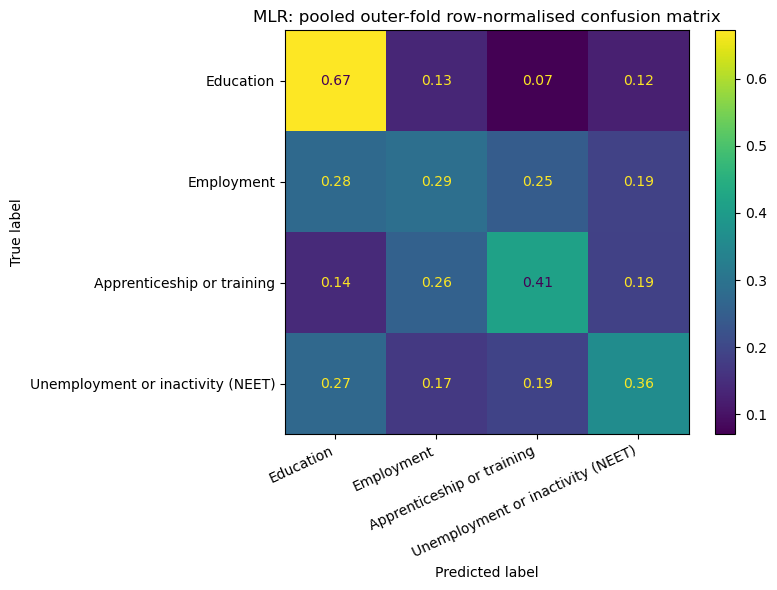

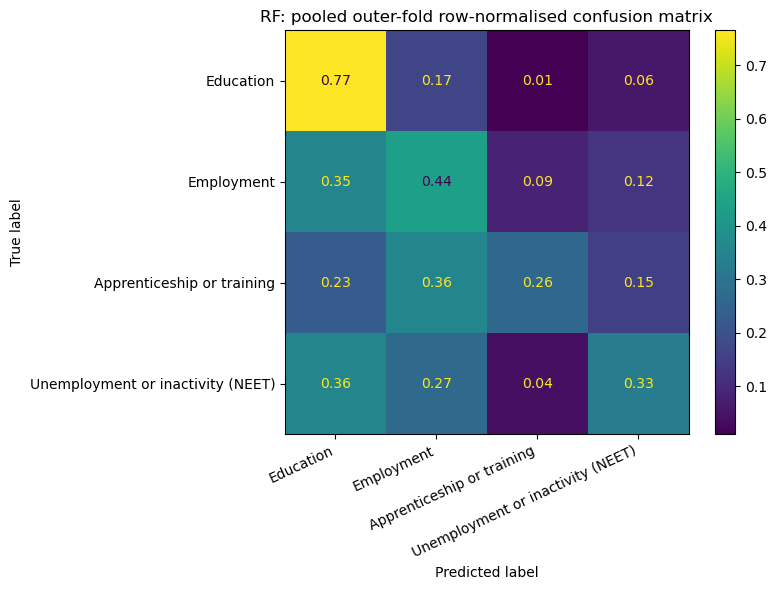

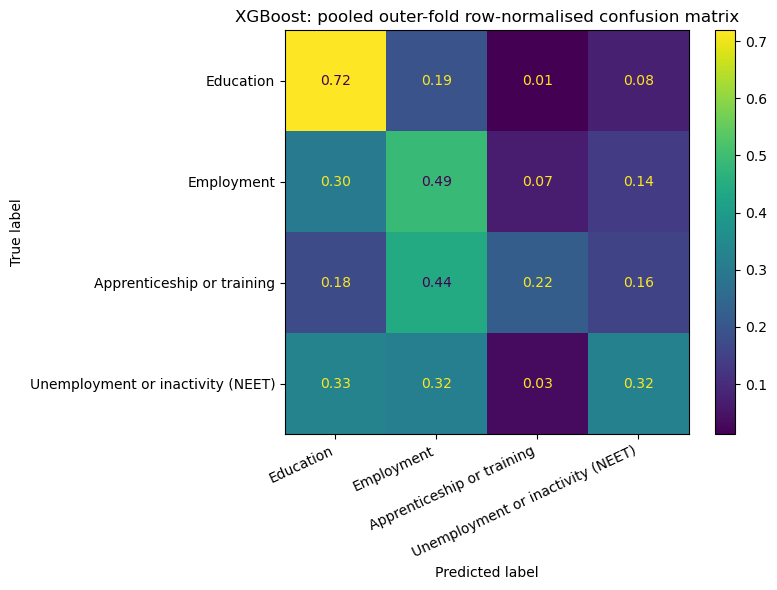

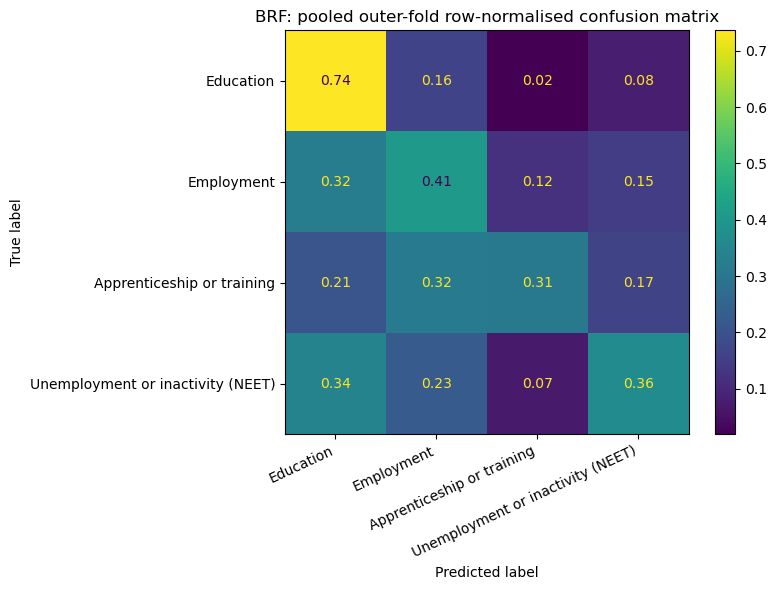

Saved: data_derived\stage_5_nested_model_development\stage_5_pooled_confusion_diagnostics.csv


In [27]:
# 19: Create pooled confusion-matrix diagnostics

selected_predictions = pd.read_csv(
    OUTPUT_FILES["predictions"],
    dtype={"NSID": "string"},
    keep_default_na=False,
    na_values=[""],
)

confusion_rows = []

for model_name in model_order:
    model_predictions = selected_predictions.loc[
        selected_predictions["Model"].eq(model_name)
    ].copy()

    if model_predictions.empty:
        continue

    y_true = model_predictions["Actual internal class"].astype(int)
    y_pred = model_predictions["Predicted internal class"].astype(int)

    counts = confusion_matrix(
        y_true,
        y_pred,
        labels=class_order,
    )

    row_totals = counts.sum(axis=1, keepdims=True)
    proportions = np.divide(
        counts,
        row_totals,
        out=np.zeros_like(counts, dtype=float),
        where=row_totals != 0,
    )

    for actual_index, actual_class in enumerate(class_order):
        for predicted_index, predicted_class in enumerate(class_order):
            confusion_rows.append(
                {
                    "Model": model_name,
                    "Actual outcome": internal_to_outcome[actual_class],
                    "Predicted outcome": internal_to_outcome[predicted_class],
                    "Count": int(counts[actual_index, predicted_index]),
                    "Row proportion": proportions[
                        actual_index,
                        predicted_index,
                    ],
                }
            )

    if model_name != "Majority-class dummy":
        figure, axis = plt.subplots(figsize=(8, 6))
        display_object = ConfusionMatrixDisplay(
            confusion_matrix=proportions,
            display_labels=class_labels,
        )
        display_object.plot(
            ax=axis,
            values_format=".2f",
        )
        axis.set_title(
            f"{model_name}: pooled outer-fold row-normalised confusion matrix"
        )
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.show()

confusion_diagnostics = pd.DataFrame(confusion_rows)

confusion_path = (
    stage_5_directory / "stage_5_pooled_confusion_diagnostics.csv"
)
confusion_diagnostics.to_csv(
    confusion_path,
    index=False,
)

print(f"Saved: {confusion_path.relative_to(project_root)}")

In [28]:
# 20: Compare observed and predicted class distributions


distribution_rows = []

for model_name, group in selected_predictions.groupby(
    "Model",
    sort=False,
):
    total = len(group)

    observed_counts = (
        group["Actual outcome"]
        .value_counts()
        .reindex(class_labels, fill_value=0)
    )

    predicted_counts = (
        group["Predicted outcome"]
        .value_counts()
        .reindex(class_labels, fill_value=0)
    )

    for outcome in class_labels:
        distribution_rows.append(
            {
                "Model": model_name,
                "Outcome": outcome,
                "Observed count": int(observed_counts[outcome]),
                "Observed proportion": observed_counts[outcome] / total,
                "Predicted count": int(predicted_counts[outcome]),
                "Predicted proportion": predicted_counts[outcome] / total,
            }
        )

distribution_summary = pd.DataFrame(distribution_rows)

distribution_path = (
    stage_5_directory / "stage_5_observed_predicted_distributions.csv"
)
distribution_summary.to_csv(
    distribution_path,
    index=False,
)

display(distribution_summary.round(4))
print(f"Saved: {distribution_path.relative_to(project_root)}")

,Model,Outcome,Observed count,Observed proportion,Predicted count,Predicted proportion
0,Majority-class dummy,Education,3961,0.5199,7619,1.0000
1,Majority-class dummy,Employment,2241,0.2941,0,0.0000
2,Majority-class dummy,Apprenticeship or training,416,0.0546,0,0.0000
3,Majority-class dummy,Unemployment or inactivity (NEET),1001,0.1314,0,0.0000
4,MLR,Education,3961,0.5199,3613,0.4742
5,MLR,Employment,2241,0.2941,1460,0.1916
6,MLR,Apprenticeship or training,416,0.0546,1192,0.1565
7,MLR,Unemployment or inactivity (NEET),1001,0.1314,1354,0.1777
8,RF,Education,3961,0.5199,4276,0.5612
9,RF,Employment,2241,0.2941,2057,0.2700


Saved: data_derived\stage_5_nested_model_development\stage_5_observed_predicted_distributions.csv


## Part 8: Completion audit

In [29]:
# 21: Final Stage 5 audit

required_models = {
    "Majority-class dummy",
    "MLR",
    "RF",
    "XGBoost",
    "BRF",
}

selected_model_predictions = set(selected_predictions["Model"].unique())
selected_model_performance = set(selected_outer_performance["Model"].unique())

model_prediction_counts = (
    selected_predictions
    .groupby("Model")["NSID"]
    .nunique()
)

xgb_regime_candidate_counts = (
    candidate_register.loc[candidate_register["Model"].eq("XGBoost")]
    .groupby("XGBoost regime ID")["Candidate ID"]
    .nunique()
)

final_checks = {
    "All required model outputs are present": required_models
        == selected_model_predictions
        == selected_model_performance,
    "Each model has five outer-fold performance rows": (
        selected_outer_performance
        .groupby("Model")["Outer fold"]
        .nunique()
        .eq(5)
        .all()
    ),
    "Mode-specific outer results match the fixed weighting design": (
        observed_mode_counts == expected_mode_counts
    ),
    "Each model has 7,619 outer-fold predictions": (
        model_prediction_counts
        .reindex(required_models)
        .eq(7_619)
        .all()
    ),
    "No selected prediction contains a test identifier": set(
        selected_predictions["NSID"]
    ).isdisjoint(test_ids),
    "Each participant is predicted once per model": (
        selected_predictions
        .groupby(["Model", "NSID"])
        .size()
        .eq(1)
        .all()
    ),
    "All four outcome classes appear in selected class results": (
        selected_class_performance
        .groupby("Model")["Outcome code"]
        .nunique()
        .eq(4)
        .all()
    ),
    "MLR search used nine structural candidates": (
        candidate_register.loc[
            candidate_register["Model"].eq("MLR"),
            "Candidate ID",
        ].nunique() == 9
    ),
    "RF search used 60 structural candidates": (
        candidate_register.loc[
            candidate_register["Model"].eq("RF"),
            "Candidate ID",
        ].nunique() == 60
    ),
    "XGBoost search used 60 structural candidates": (
        candidate_register.loc[
            candidate_register["Model"].eq("XGBoost"),
            "Candidate ID",
        ].nunique() == 60
    ),
    "XGBoost used five candidates in each of 12 regimes": (
        len(xgb_regime_candidate_counts) == 12
        and xgb_regime_candidate_counts.eq(5).all()
    ),
    "BRF used the same 60 tree structures as RF": (
        [json.dumps(x, sort_keys=True) for x in rf_candidates]
        == [json.dumps(x, sort_keys=True) for x in brf_candidates]
    ),
    "Candidate coverage contains all prespecified levels": (
        not candidate_coverage.empty
    ),
}

final_audit = pd.DataFrame(
    {
        "Check": list(final_checks.keys()),
        "Passed": list(final_checks.values()),
    }
)

final_audit_path = stage_5_directory / "stage_5_final_audit.csv"
final_audit.to_csv(final_audit_path, index=False)

display(final_audit)

if not final_audit["Passed"].all():
    failed = final_audit.loc[~final_audit["Passed"], "Check"].tolist()
    raise AssertionError("Stage 5 final audit failed: " + "; ".join(failed))

output_manifest = pd.DataFrame(
    [
        ["stage_5_hyperparameter_candidates.csv", "Fixed structural candidate register", "Stage 5-1; audit"],
        ["stage_5_candidate_coverage.csv", "Candidate-space coverage", "Audit; methodology"],
        ["stage_5_search_specification.csv", "Model-search design used in Stage 5", "Stage 5-1; Stage 6"],
        ["stage_5_inner_search_results.csv", "Inner-CV macro-F1 search results", "Audit; model development"],
        ["stage_5_outer_selection_register.csv", "Configuration selected within each outer fold", "Stage 5-1"],
        ["stage_5_outer_performance.csv", "Outer-fold overall metrics", "Results; evaluation"],
        ["stage_5_outer_class_performance.csv", "Outer-fold destination-specific metrics", "Results; evaluation"],
        ["stage_5_selected_outer_predictions.csv", "Participant-level outer-validation predictions", "Local diagnostics"],
        ["stage_5_outer_performance_summary.csv", "Mean and SD of outer-fold overall metrics", "Results"],
        ["stage_5_outer_class_performance_summary.csv", "Mean and SD of destination-specific metrics", "Results"],
        ["stage_5_weighting_mode_summary.csv", "Performance by fitting mode", "Results; imbalance evaluation"],
        ["stage_5_weighting_selection_stability.csv", "Outer-fold fitting-mode selections", "Model-development diagnostics"],
        ["stage_5_candidate_selection_stability.csv", "Outer-fold candidate selections", "Model-development diagnostics"],
        ["stage_5_pooled_confusion_diagnostics.csv", "Pooled confusion counts and row proportions", "Diagnostics"],
        ["stage_5_observed_predicted_distributions.csv", "Observed and predicted destination distributions", "Diagnostics"],
        ["stage_5_final_audit.csv", "Stage 5 completion checks", "Audit"],
    ],
    columns=["File", "Content", "Use"],
)

output_manifest["Path"] = output_manifest["File"].map(
    lambda name: str((stage_5_directory / name).relative_to(project_root))
)
output_manifest["Exists"] = output_manifest["File"].map(
    lambda name: (stage_5_directory / name).is_file()
)

output_manifest_path = stage_5_directory / "stage_5_output_manifest.csv"
output_manifest.to_csv(output_manifest_path, index=False)

print("\nStage 5 nested model development is complete.")
print(f"Saved: {final_audit_path.relative_to(project_root)}")
print(f"Saved: {output_manifest_path.relative_to(project_root)}")

,Check,Passed
0,All required model outputs are present,True
1,Each model has five outer-fold performance rows,True
2,Mode-specific outer results match the fixed we...,True
3,"Each model has 7,619 outer-fold predictions",True
4,No selected prediction contains a test identifier,True
5,Each participant is predicted once per model,True
6,All four outcome classes appear in selected cl...,True
7,MLR search used nine structural candidates,True
8,RF search used 60 structural candidates,True
9,XGBoost search used 60 structural candidates,True



Stage 5 nested model development is complete.
Saved: data_derived\stage_5_nested_model_development\stage_5_final_audit.csv
Saved: data_derived\stage_5_nested_model_development\stage_5_output_manifest.csv


## Stage 5 summary

Nested model development produces one outer-validation prediction per training participant for each model. Performance summaries, class-specific results, selection records and diagnostic outputs are generated from these predictions. Final evaluation remains separate from this development stage.